In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_auc_score,
    mean_absolute_error, mean_squared_error, r2_score
)

import warnings
warnings.filterwarnings("ignore")
print("Imported successfully")

Imported successfully


In [ ]:
df = pd.read_csv("india_housing_prices.csv")

In [ ]:
df.head()

,ID,State,City,Locality,Property_Type,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,...,Age_of_Property,Nearby_Schools,Nearby_Hospitals,Public_Transport_Accessibility,Parking_Space,Security,Amenities,Facing,Owner_Type,Availability_Status
0,1,Tamil Nadu,Chennai,Locality_84,Apartment,1,4740,489.76,0.10,1990,...,35,10,3,High,No,No,"Playground, Gym, Garden, Pool, Clubhouse",West,Owner,Ready_to_Move
1,2,Maharashtra,Pune,Locality_490,Independent House,3,2364,195.52,0.08,2008,...,17,8,1,Low,No,Yes,"Playground, Clubhouse, Pool, Gym, Garden",North,Builder,Under_Construction
2,3,Punjab,Ludhiana,Locality_167,Apartment,2,3642,183.79,0.05,1997,...,28,9,8,Low,Yes,No,"Clubhouse, Pool, Playground, Gym",South,Broker,Ready_to_Move
3,4,Rajasthan,Jodhpur,Locality_393,Independent House,2,2741,300.29,0.11,1991,...,34,5,7,High,Yes,Yes,"Playground, Clubhouse, Gym, Pool, Garden",North,Builder,Ready_to_Move
4,5,Rajasthan,Jaipur,Locality_466,Villa,4,4823,182.90,0.04,2002,...,23,4,9,Low,No,Yes,"Playground, Garden, Gym, Pool, Clubhouse",East,Builder,Ready_to_Move


In [ ]:
df.shape

(250000, 23)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 23 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   ID                              250000 non-null  int64  
 1   State                           250000 non-null  object 
 2   City                            250000 non-null  object 
 3   Locality                        250000 non-null  object 
 4   Property_Type                   250000 non-null  object 
 5   BHK                             250000 non-null  int64  
 6   Size_in_SqFt                    250000 non-null  int64  
 7   Price_in_Lakhs                  250000 non-null  float64
 8   Price_per_SqFt                  250000 non-null  float64
 9   Year_Built                      250000 non-null  int64  
 10  Furnished_Status                250000 non-null  object 
 11  Floor_No                        250000 non-null  int64  
 12  Total_Floors    

In [ ]:
df.describe()

,ID,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,Floor_No,Total_Floors,Age_of_Property,Nearby_Schools,Nearby_Hospitals
count,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000
mean,125000.500000,2.999396,2749.813216,254.586854,0.130597,2006.520012,14.966800,15.503004,18.479988,5.499860,5.498016
std,72168.927986,1.415521,1300.606954,141.349921,0.130747,9.808575,8.948047,8.671618,9.808575,2.878639,2.871860
min,1.000000,1.000000,500.000000,10.000000,0.000000,1990.000000,0.000000,1.000000,2.000000,1.000000,1.000000
25%,62500.750000,2.000000,1623.000000,132.550000,0.050000,1998.000000,7.000000,8.000000,10.000000,3.000000,3.000000
50%,125000.500000,3.000000,2747.000000,253.870000,0.090000,2007.000000,15.000000,15.000000,18.000000,5.000000,5.000000
75%,187500.250000,4.000000,3874.000000,376.880000,0.160000,2015.000000,23.000000,23.000000,27.000000,8.000000,8.000000
max,250000.000000,5.000000,5000.000000,500.000000,0.990000,2023.000000,30.000000,30.000000,35.000000,10.000000,10.000000


In [ ]:
# Checking missing values
df.isnull().sum()

,0
ID,0
State,0
City,0
Locality,0
Property_Type,0
BHK,0
Size_in_SqFt,0
Price_in_Lakhs,0
Price_per_SqFt,0
Year_Built,0


In [ ]:
# Checking duplicates
df.duplicated().sum()

np.int64(0)

In [ ]:
df = df.drop_duplicates()

In [ ]:
# Columns
df.columns

Index(['ID', 'State', 'City', 'Locality', 'Property_Type', 'BHK',
       'Size_in_SqFt', 'Price_in_Lakhs', 'Price_per_SqFt', 'Year_Built',
       'Furnished_Status', 'Floor_No', 'Total_Floors', 'Age_of_Property',
       'Nearby_Schools', 'Nearby_Hospitals', 'Public_Transport_Accessibility',
       'Parking_Space', 'Security', 'Amenities', 'Facing', 'Owner_Type',
       'Availability_Status'],
      dtype='object')

STEP - 1:
DATA PREPROCESSING


In [ ]:
# Removing unneccesary columns
df = df.drop(columns=["ID"])

In [ ]:
df.dtypes

,0
State,object
City,object
Locality,object
Property_Type,object
BHK,int64
Size_in_SqFt,int64
Price_in_Lakhs,float64
Price_per_SqFt,float64
Year_Built,int64
Furnished_Status,object


In [ ]:
# Handling missing values
# Numerical columns
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

In [ ]:
# Categorical columns
cat_cols = df.select_dtypes(include="object").columns
df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])

In [ ]:
df.isnull().sum().sum()

np.int64(0)

FEATURE ENGINEERING

In [ ]:
# Verifying Price_per_SqFt
df["Calculated_Price_per_SqFt"] = (
    df["Price_in_Lakhs"] * 100000
) / df["Size_in_SqFt"]

df[["Price_in_Lakhs", "Size_in_SqFt", "Price_per_SqFt",
    "Calculated_Price_per_SqFt"]].head()

,Price_in_Lakhs,Size_in_SqFt,Price_per_SqFt,Calculated_Price_per_SqFt
0,489.76,4740,0.10,10332.489451
1,195.52,2364,0.08,8270.727580
2,183.79,3642,0.05,5046.403075
3,300.29,2741,0.11,10955.490697
4,182.90,4823,0.04,3792.245490


In [ ]:
df.drop(columns=["Calculated_Price_per_SqFt"], inplace=True)

In [ ]:
# Calculating the age of property
current_year = 2026

df["Calculated_Age"] = current_year - df["Year_Built"]

df[["Year_Built", "Age_of_Property", "Calculated_Age"]].head()

,Year_Built,Age_of_Property,Calculated_Age
0,1990,35,36
1,2008,17,18
2,1997,28,29
3,1991,34,35
4,2002,23,24


In [ ]:
df.drop(columns=["Calculated_Age"], inplace=True)

CREATING TARGET VARIABLES


In [ ]:
# Creating  good investment
median_price = df["Price_in_Lakhs"].median()

df["Good_Investment"] = (
    df["Price_in_Lakhs"] <= median_price
).astype(int)

In [ ]:
df["Good_Investment"].value_counts()

,count
Good_Investment,
1,125001
0,124999


In [ ]:
# Creating Future_Price_5Y
growth_rate = 0.08
years = 5

df["Future_Price_5Y"] = (
    df["Price_in_Lakhs"] *
    ((1 + growth_rate) ** years)
)

In [ ]:
df[["Price_in_Lakhs", "Future_Price_5Y"]].head()

,Price_in_Lakhs,Future_Price_5Y
0,489.76,719.618119
1,195.52,287.283026
2,183.79,270.047807
3,300.29,441.224528
4,182.90,268.740105


STEP - 2: EDA

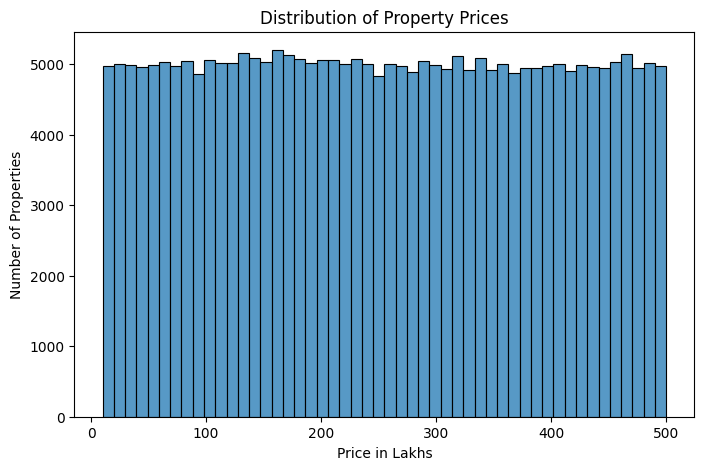

In [ ]:
# Price distribution
plt.figure(figsize=(8,5))
sns.histplot(df["Price_in_Lakhs"], bins=50)
plt.title("Distribution of Property Prices")
plt.xlabel("Price in Lakhs")
plt.ylabel("Number of Properties")
plt.show()

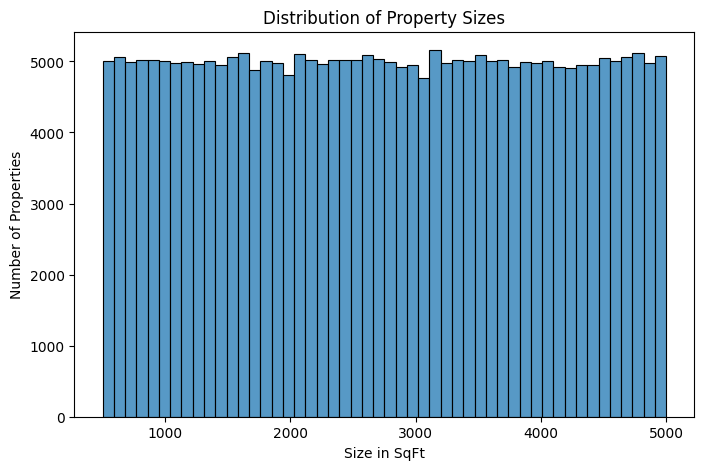

In [ ]:
# Size distribution
plt.figure(figsize=(8,5))
sns.histplot(df["Size_in_SqFt"], bins=50)
plt.title("Distribution of Property Sizes")
plt.xlabel("Size in SqFt")
plt.ylabel("Number of Properties")
plt.show()

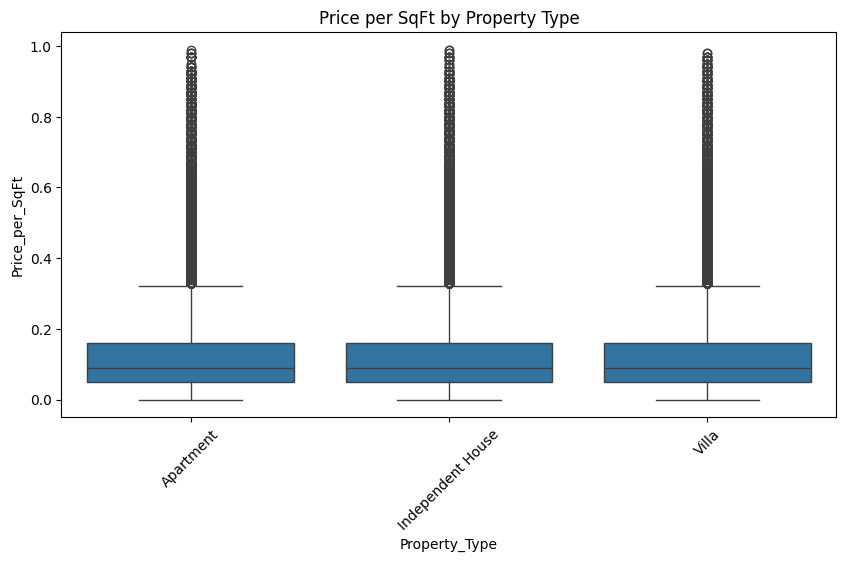

In [ ]:
# Price per sqft by property type
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x="Property_Type", y="Price_per_SqFt")
plt.xticks(rotation=45)
plt.title("Price per SqFt by Property Type")
plt.show()

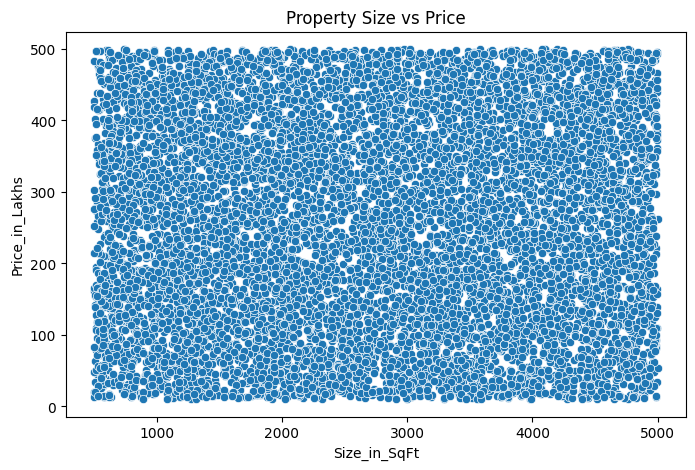

In [ ]:
# Size vs price
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df.sample(min(10000, len(df))),
    x="Size_in_SqFt",
    y="Price_in_Lakhs"
)
plt.title("Property Size vs Price")
plt.show()

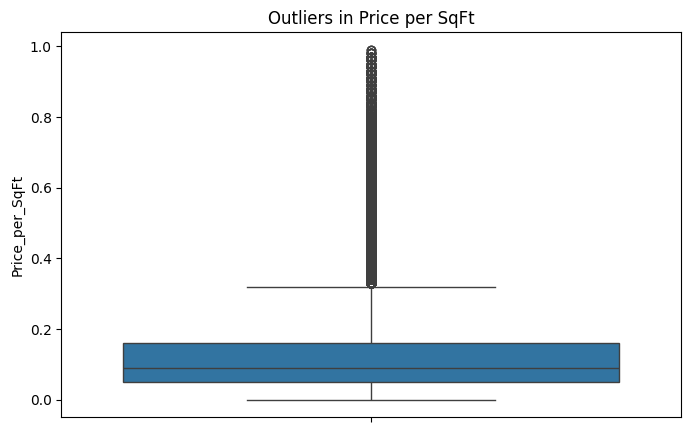

In [ ]:
# Outliers
plt.figure(figsize=(8,5))
sns.boxplot(y=df["Price_per_SqFt"])
plt.title("Outliers in Price per SqFt")
plt.show()

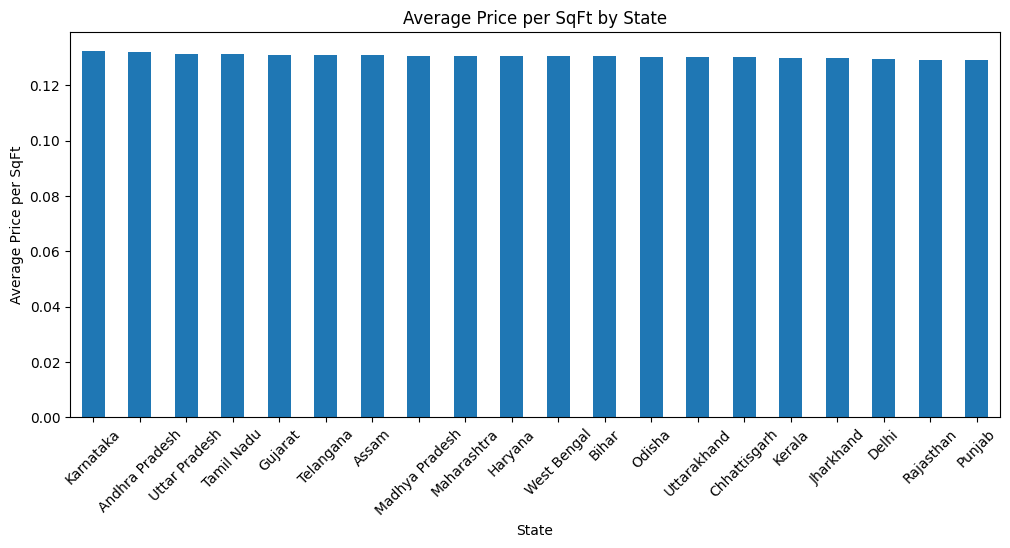

In [ ]:
# Average price per sqft by state
state_price = (
    df.groupby("State")["Price_per_SqFt"]
    .mean()
    .sort_values(ascending=False)
)

state_price.plot(kind="bar", figsize=(12,5))
plt.title("Average Price per SqFt by State")
plt.ylabel("Average Price per SqFt")
plt.xticks(rotation=45)
plt.show()

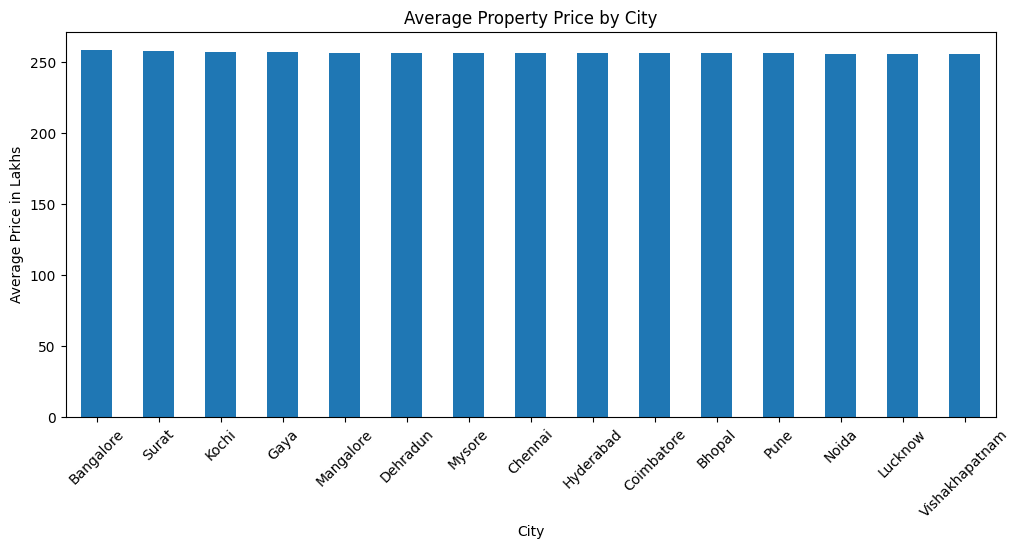

In [ ]:
# Average property price by city
city_price = (
    df.groupby("City")["Price_in_Lakhs"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

city_price.plot(kind="bar", figsize=(12,5))
plt.title("Average Property Price by City")
plt.ylabel("Average Price in Lakhs")
plt.xticks(rotation=45)
plt.show()

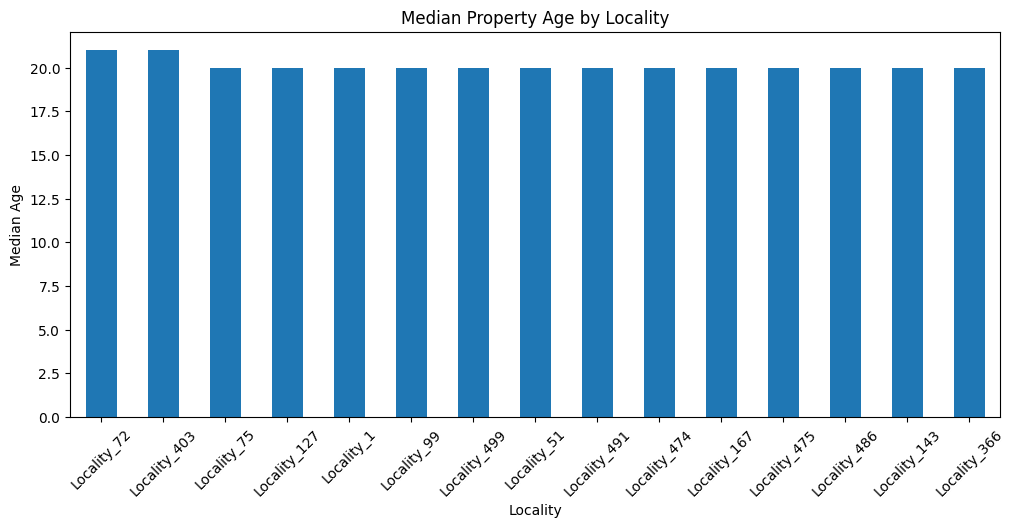

In [ ]:
# Median age by locality
locality_age = (
    df.groupby("Locality")["Age_of_Property"]
    .median()
    .sort_values(ascending=False)
    .head(15)
)

locality_age.plot(kind="bar", figsize=(12,5))
plt.title("Median Property Age by Locality")
plt.ylabel("Median Age")
plt.xticks(rotation=45)
plt.show()

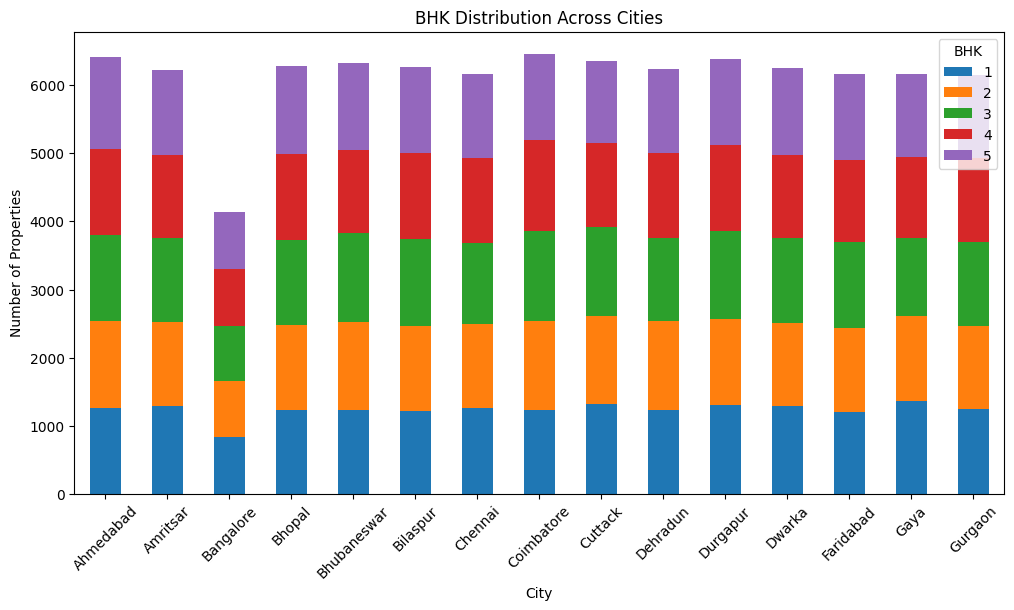

In [ ]:
# BHK distribution across cities
bhk_city = pd.crosstab(df["City"], df["BHK"])

bhk_city.head(15).plot(
    kind="bar",
    stacked=True,
    figsize=(12,6)
)

plt.title("BHK Distribution Across Cities")
plt.xlabel("City")
plt.ylabel("Number of Properties")
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Top 5 expensive localities
top_localities = (
    df.groupby("Locality")["Price_in_Lakhs"]
    .mean()
    .sort_values(ascending=False)
    .head(5)
)

top_localities

,Price_in_Lakhs
Locality,
Locality_395,275.425987
Locality_366,273.411996
Locality_497,269.995540
Locality_360,269.806792
Locality_203,269.033716


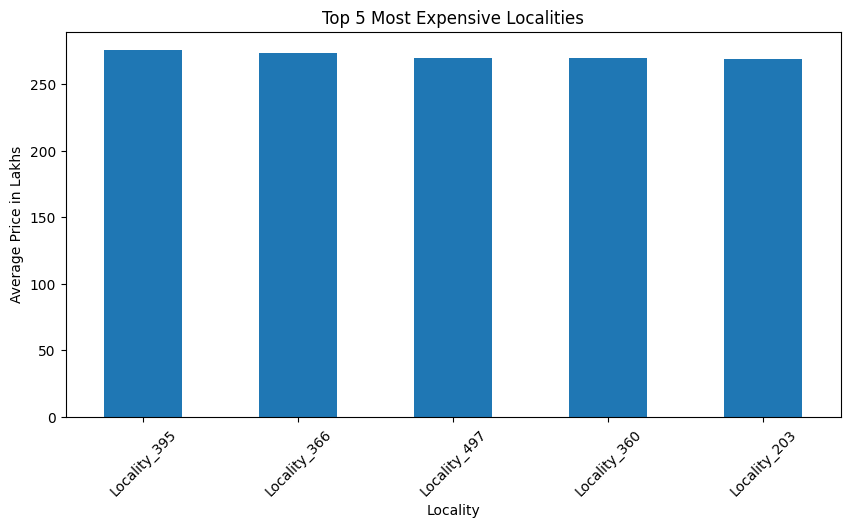

In [ ]:
top_localities.plot(kind="bar", figsize=(10,5))
plt.title("Top 5 Most Expensive Localities")
plt.ylabel("Average Price in Lakhs")
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Feature relationship

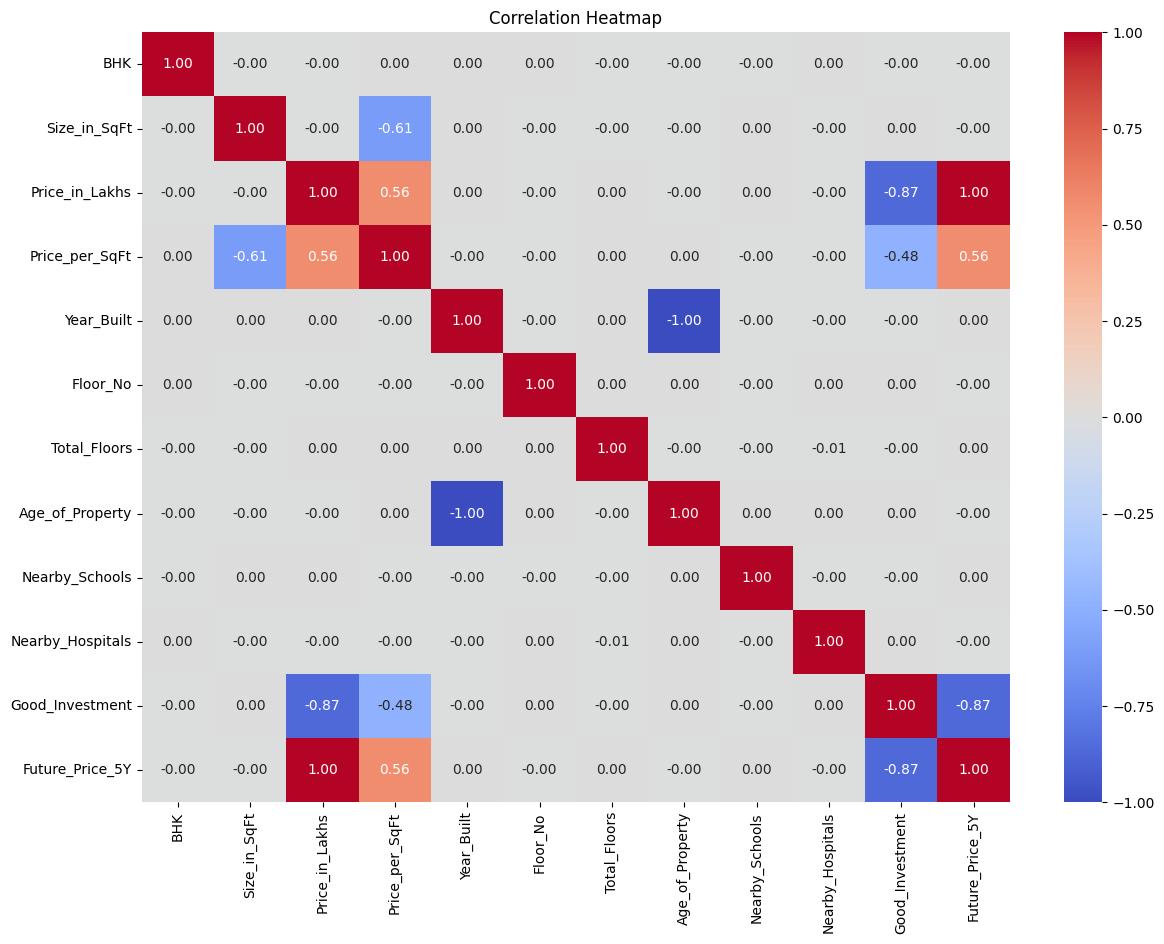

In [ ]:
# Correlation heatmap
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(14,10))
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

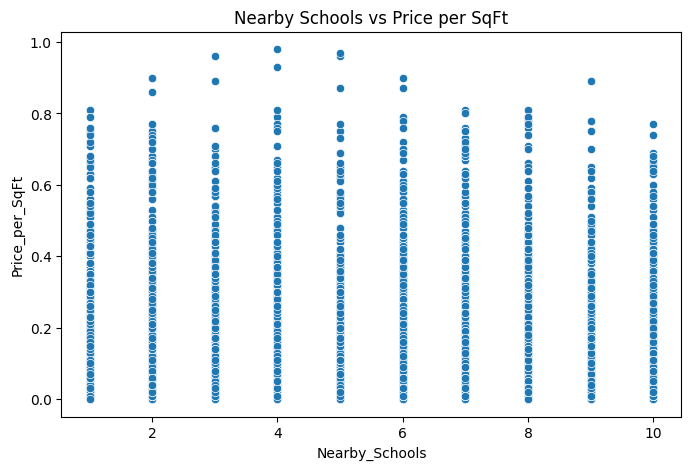

In [ ]:
# Schools vs price per sqft
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df.sample(min(10000, len(df))),
    x="Nearby_Schools",
    y="Price_per_SqFt"
)

plt.title("Nearby Schools vs Price per SqFt")
plt.show()

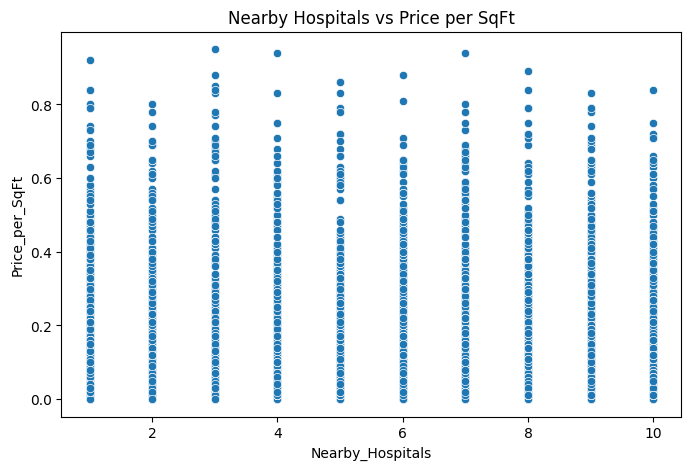

In [ ]:
# Hospitals vs price per sqft
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df.sample(min(10000, len(df))),
    x="Nearby_Hospitals",
    y="Price_per_SqFt"
)

plt.title("Nearby Hospitals vs Price per SqFt")
plt.show()


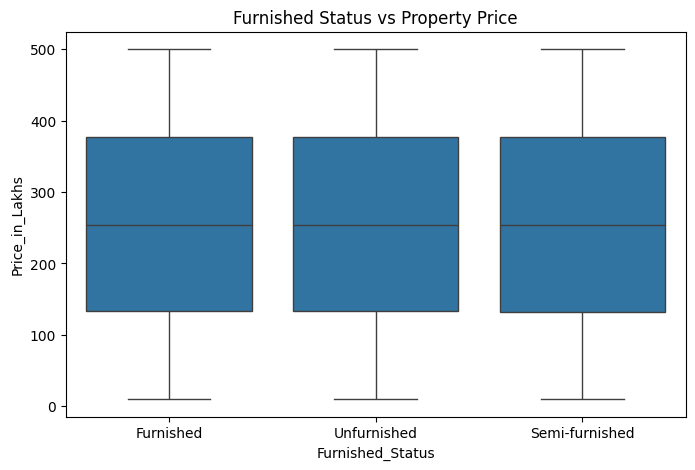

In [ ]:
# Furnished status vs price
plt.figure(figsize=(8,5))
sns.boxplot(
    data=df,
    x="Furnished_Status",
    y="Price_in_Lakhs"
)

plt.title("Furnished Status vs Property Price")
plt.show()

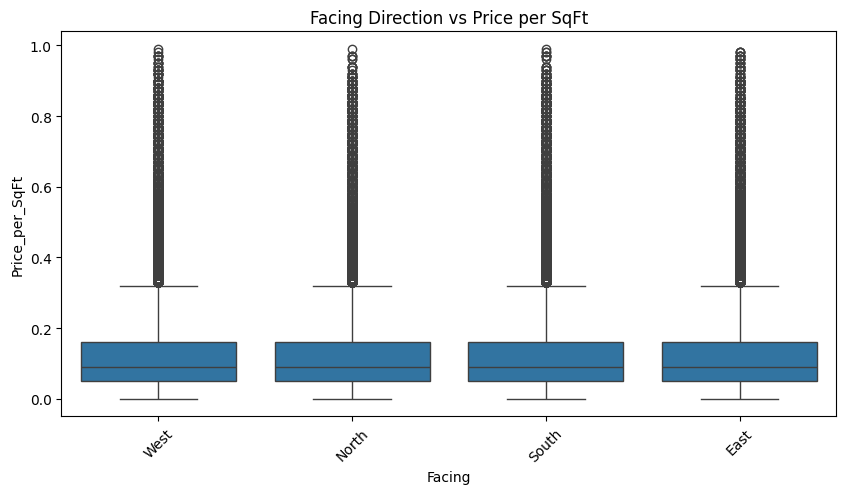

In [ ]:
# Facing vs price per sqft
plt.figure(figsize=(10,5))
sns.boxplot(
    data=df,
    x="Facing",
    y="Price_per_SqFt"
)

plt.title("Facing Direction vs Price per SqFt")
plt.xticks(rotation=45)
plt.show()

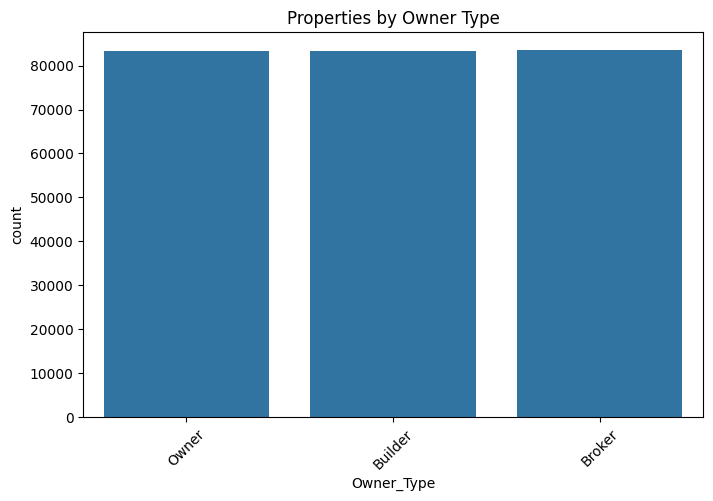

In [ ]:
# Owner type
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="Owner_Type")
plt.title("Properties by Owner Type")
plt.xticks(rotation=45)
plt.show()

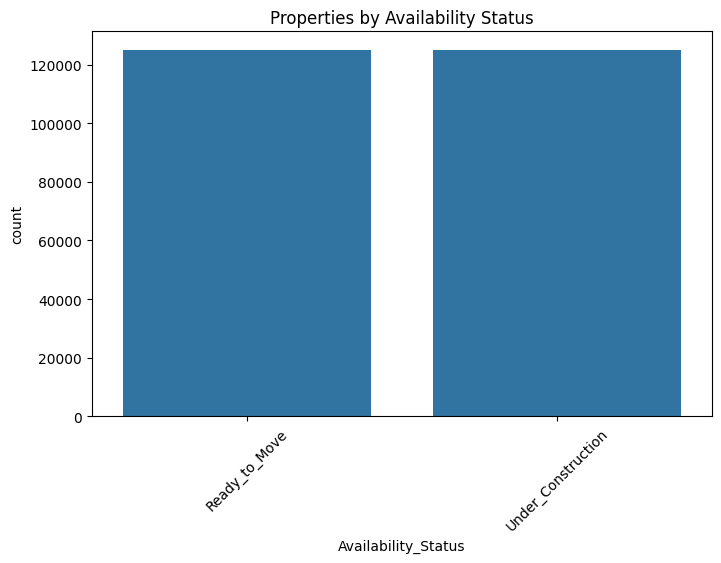

In [ ]:
# Availability status
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="Availability_Status")
plt.title("Properties by Availability Status")
plt.xticks(rotation=45)
plt.show()

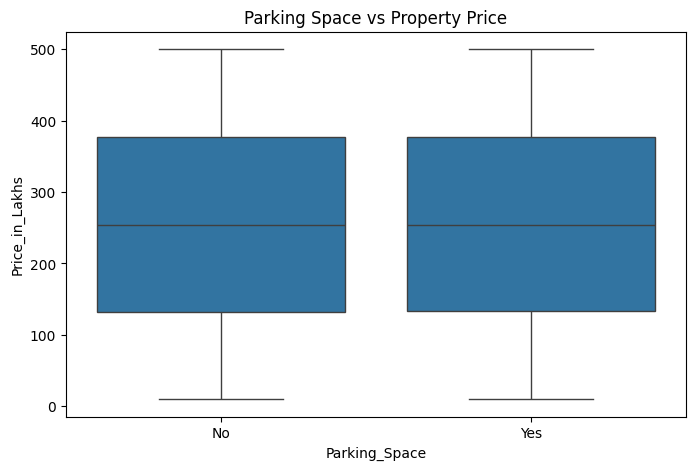

In [ ]:
# Parking vs price
plt.figure(figsize=(8,5))
sns.boxplot(
    data=df,
    x="Parking_Space",
    y="Price_in_Lakhs"
)

plt.title("Parking Space vs Property Price")
plt.show()

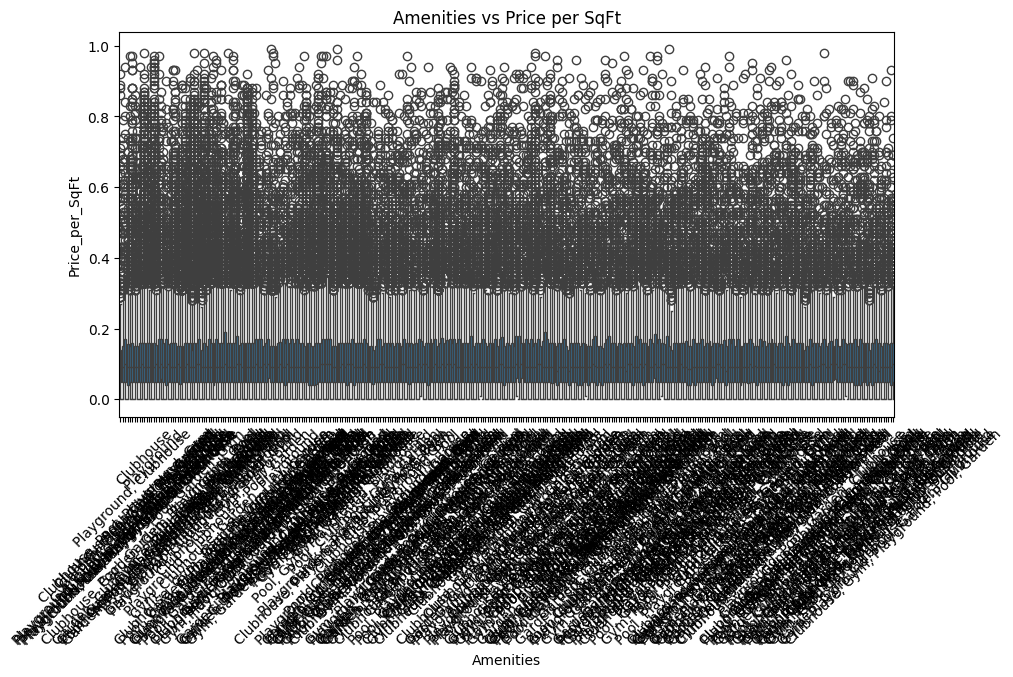

In [ ]:
# Amenities vs price per sqft
plt.figure(figsize=(10,5))
sns.boxplot(
    data=df,
    x="Amenities",
    y="Price_per_SqFt"
)

plt.xticks(rotation=45)
plt.title("Amenities vs Price per SqFt")
plt.show()

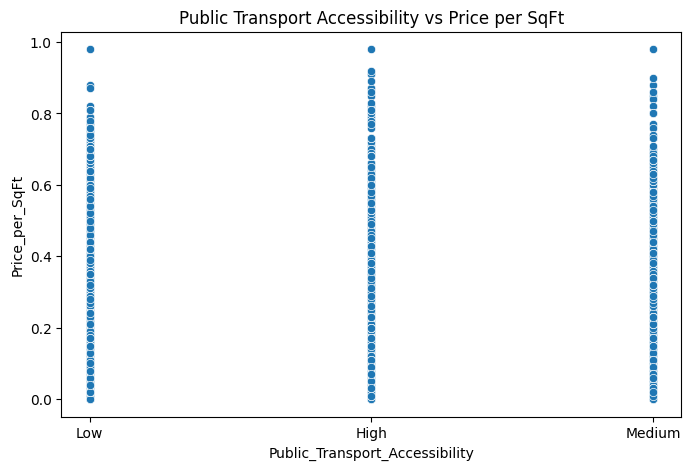

In [ ]:
# Public transport vs price
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df.sample(min(10000, len(df))),
    x="Public_Transport_Accessibility",
    y="Price_per_SqFt"
)

plt.title("Public Transport Accessibility vs Price per SqFt")
plt.show()

STEP - 3: MODEL DEVELOPMENT

In [ ]:
# Preparing X and y
# For classification
X = df.drop(columns=["Good_Investment", "Future_Price_5Y"])
y_classification = df["Good_Investment"]

In [ ]:
# For regression
y_regression = df["Future_Price_5Y"]


In [ ]:
# Identifying numerical and categorical columns
numeric_features = X.select_dtypes(include=np.number).columns.tolist()

categorical_features = X.select_dtypes(include="object").columns.tolist()

print("Numerical:", numeric_features)
print("Categorical:", categorical_features)

Numerical: ['BHK', 'Size_in_SqFt', 'Price_in_Lakhs', 'Price_per_SqFt', 'Year_Built', 'Floor_No', 'Total_Floors', 'Age_of_Property', 'Nearby_Schools', 'Nearby_Hospitals']
Categorical: ['State', 'City', 'Locality', 'Property_Type', 'Furnished_Status', 'Public_Transport_Accessibility', 'Parking_Space', 'Security', 'Amenities', 'Facing', 'Owner_Type', 'Availability_Status']


In [ ]:
# Preprocessing pipeline
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=True
        ))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

CLASSIFICATION

In [ ]:
y_classification = df["Good_Investment"]

In [ ]:
X_classification = df.drop(
    columns=["Good_Investment", "Future_Price_5Y"]
)

In [ ]:
# Train-test split
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X,
    y_classification,
    test_size=0.2,
    random_state=42,
    stratify=y_classification
)

In [ ]:
# Identifying Numerical and Categorical Features
numeric_features = X_classification.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_classification.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['BHK', 'Size_in_SqFt', 'Price_in_Lakhs', 'Price_per_SqFt', 'Year_Built', 'Floor_No', 'Total_Floors', 'Age_of_Property', 'Nearby_Schools', 'Nearby_Hospitals']

Categorical Features:
['State', 'City', 'Locality', 'Property_Type', 'Furnished_Status', 'Public_Transport_Accessibility', 'Parking_Space', 'Security', 'Amenities', 'Facing', 'Owner_Type', 'Availability_Status']


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=True
    ))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

In [ ]:
# Logistic Regression
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000))
    ]
)

logistic_model.fit(X_train_c, y_train_c)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['BHK', 'Size_in_SqFt',
                                                   'Price_in_Lakhs',
                                                   'Price_per_SqFt',
                                                   'Year_Built', 'Floor_No',
                                                   'Total_Floors',
                                                   'Age_of_Property',
                                                   'Nearby_Schools',
                                                   'Nearby_Hospitals']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['State', 'City', 'Locality',
                                                   'Property_Type',
                                                   'Furnished_Status',
                                                   'Public_Transport_Accessibility',
                                                   'Parking_Space', 'Security',
                                                   'Amenities', 'Facing',
                                                   'Owner_Type',
                                                   'Availability_Status'])])),
                ('classifier', LogisticRegression(max_iter=1000))])

In [ ]:
y_pred_logistic = logistic_model.predict(X_test_c)

y_prob_logistic = logistic_model.predict_proba(
    X_test_c
)[:, 1]

In [ ]:
# Evaluating Logistic Regression
logistic_accuracy = accuracy_score(
    y_test_c,
    y_pred_logistic
)

logistic_precision = precision_score(
    y_test_c,
    y_pred_logistic
)

logistic_recall = recall_score(
    y_test_c,
    y_pred_logistic
)

logistic_f1 = f1_score(
    y_test_c,
    y_pred_logistic
)

logistic_auc = roc_auc_score(
    y_test_c,
    y_prob_logistic
)

print("Logistic Regression")
print("Accuracy :", logistic_accuracy)
print("Precision:", logistic_precision)
print("Recall   :", logistic_recall)
print("F1 Score :", logistic_f1)
print("ROC AUC  :", logistic_auc)

Logistic Regression
Accuracy : 0.9991
Precision: 0.9992797407066544
Recall   : 0.99892
F1 Score : 0.9990998379708348
ROC AUC  : 0.9999975296


In [ ]:
# Random Forest Classifier
rf_classifier = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

rf_classifier.fit(X_train_c, y_train_c)



Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['BHK', 'Size_in_SqFt',
                                                   'Price_in_Lakhs',
                                                   'Price_per_SqFt',
                                                   'Year_Built', 'Floor_No',
                                                   'Total_Floors',
                                                   'Age_of_Property',
                                                   'Nearby_Schools',
                                                   'Nearby_Hospitals']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['State', 'City', 'Locality',
                                                   'Property_Type',
                                                   'Furnished_Status',
                                                   'Public_Transport_Accessibility',
                                                   'Parking_Space', 'Security',
                                                   'Amenities', 'Facing',
                                                   'Owner_Type',
                                                   'Availability_Status'])])),
                ('classifier',
                 RandomForestClassifier(n_jobs=-1, random_state=42))])

In [ ]:
y_pred_rf = rf_classifier.predict(X_test_c)

y_prob_rf = rf_classifier.predict_proba(
    X_test_c
)[:, 1]

In [ ]:
# Evaluating Random Forest Classifier
rf_accuracy = accuracy_score(
    y_test_c,
    y_pred_rf
)

rf_precision = precision_score(
    y_test_c,
    y_pred_rf
)

rf_recall = recall_score(
    y_test_c,
    y_pred_rf
)

rf_f1 = f1_score(
    y_test_c,
    y_pred_rf
)

rf_auc = roc_auc_score(
    y_test_c,
    y_prob_rf
)

print("Random Forest")
print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1 Score :", rf_f1)
print("ROC AUC  :", rf_auc)

Random Forest
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0
ROC AUC  : 1.0


In [ ]:
!pip install xgboost -q

In [ ]:
# XGBoost Classifier
from xgboost import XGBClassifier

In [ ]:
xgb_classifier = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        random_state=42,
        eval_metric="logloss"
    ))
])

In [ ]:
xgb_classifier.fit(X_train_c, y_train_c)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['BHK', 'Size_in_SqFt',
                                                   'Price_in_Lakhs',
                                                   'Price_per_SqFt',
                                                   'Year_Built', 'Floor_No',
                                                   'Total_Floors',
                                                   'Age_of_Property',
                                                   'Nearby_Schools',
                                                   'Nearby_Hospitals']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   Sim...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=6, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=100, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [ ]:
y_pred_xgb = xgb_classifier.predict(X_test_c)

y_prob_xgb = xgb_classifier.predict_proba(
    X_test_c
)[:, 1]

In [ ]:
# Evaluating XGBoost
xgb_accuracy = accuracy_score(
    y_test_c,
    y_pred_xgb
)

xgb_precision = precision_score(
    y_test_c,
    y_pred_xgb
)

xgb_recall = recall_score(
    y_test_c,
    y_pred_xgb
)

xgb_f1 = f1_score(
    y_test_c,
    y_pred_xgb
)

xgb_auc = roc_auc_score(
    y_test_c,
    y_prob_xgb
)

print("XGBoost")
print("Accuracy :", xgb_accuracy)
print("Precision:", xgb_precision)
print("Recall   :", xgb_recall)
print("F1 Score :", xgb_f1)
print("ROC AUC  :", xgb_auc)

XGBoost
Accuracy : 0.99996
Precision: 0.9999200063994881
Recall   : 1.0
F1 Score : 0.999960001599936
ROC AUC  : 0.9999996672


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [ ]:
# Classification model comparison
classification_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],

    "Accuracy": [
        logistic_accuracy,
        rf_accuracy,
        xgb_accuracy
    ],

    "Precision": [
        logistic_precision,
        rf_precision,
        xgb_precision
    ],

    "Recall": [
        logistic_recall,
        rf_recall,
        xgb_recall
    ],

    "F1 Score": [
        logistic_f1,
        rf_f1,
        xgb_f1
    ],

    "ROC AUC": [
        logistic_auc,
        rf_auc,
        xgb_auc
    ]
})

classification_results

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.99910,0.99928,0.99892,0.99910,0.999998
1,Random Forest,1.00000,1.00000,1.00000,1.00000,1.000000
2,XGBoost,0.99996,0.99992,1.00000,0.99996,1.000000


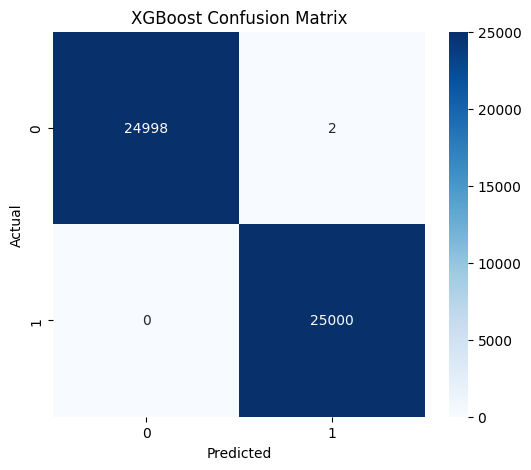

In [ ]:
# Confusion Matrix
cm = confusion_matrix(
    y_test_c,
    y_pred_xgb
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
# Classification report
print(
    classification_report(
        y_test_c,
        y_pred_xgb
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     25000
           1       1.00      1.00      1.00     25000

    accuracy                           1.00     50000
   macro avg       1.00      1.00      1.00     50000
weighted avg       1.00      1.00      1.00     50000



In [ ]:
rf_preprocessor = rf_classifier.named_steps["preprocessor"]

rf_model = rf_classifier.named_steps["classifier"]

feature_names = rf_preprocessor.get_feature_names_out()

importance = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(20)

,Feature,Importance
2,num__Price_in_Lakhs,0.651318
3,num__Price_per_SqFt,0.268518
1,num__Size_in_SqFt,0.034903
6,num__Total_Floors,0.001790
5,num__Floor_No,0.001729
7,num__Age_of_Property,0.001611
4,num__Year_Built,0.001610
8,num__Nearby_Schools,0.001398
9,num__Nearby_Hospitals,0.001396
0,num__BHK,0.001081


<Figure size 1000x600 with 0 Axes>

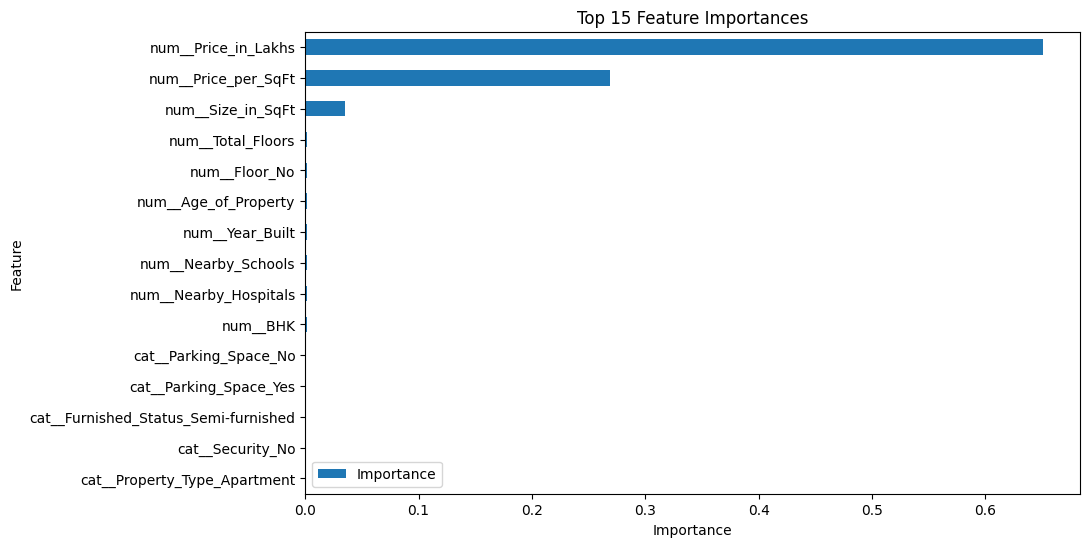

In [ ]:
plt.figure(figsize=(10,6))

feature_importance.head(15).sort_values(
    "Importance"
).plot(
    x="Feature",
    y="Importance",
    kind="barh",
    figsize=(10,6)
)

plt.title("Top 15 Feature Importances")
plt.xlabel("Importance")
plt.show()

REGRESSION

In [ ]:
X_regression = df.drop(
    columns=["Good_Investment", "Future_Price_5Y"]
)

y_regression = df["Future_Price_5Y"]

In [ ]:
# Train-test split
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X,
    y_regression,
    test_size=0.2,
    random_state=42
)

In [ ]:
# Linear Regression
from sklearn.linear_model import LinearRegression

linear_model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

linear_model.fit(
    X_train_r,
    y_train_r
)

y_pred_linear = linear_model.predict(
    X_test_r
)

In [ ]:
# Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor

rf_regressor = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(
        n_estimators=20,
        max_depth=15,
        max_features="sqrt",
        min_samples_split=2,
        min_samples_leaf=1,
        random_state=42,
        n_jobs=-1
    ))
])

rf_regressor.fit(
    X_train_r,
    y_train_r
)

y_pred_rf_reg = rf_regressor.predict(
    X_test_r
)

In [ ]:
 # XGBoost Regressor
from xgboost import XGBRegressor

xgb_regressor = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", XGBRegressor(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        random_state=42,
        objective="reg:squarederror"
    ))
])

xgb_regressor.fit(
    X_train_r,
    y_train_r
)

y_pred_xgb_reg = xgb_regressor.predict(
    X_test_r
)

In [ ]:
# Regression Metrics Function
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

def evaluate_regression(y_actual, y_pred):

    mae = mean_absolute_error(
        y_actual,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_actual,
            y_pred
        )
    )

    r2 = r2_score(
        y_actual,
        y_pred
    )

    return mae, rmse, r2

In [ ]:
# Linear Regression Metrics
mae_linear, rmse_linear, r2_linear = evaluate_regression(
    y_test_r,
    y_pred_linear
)

print("Linear Regression")
print("MAE :", mae_linear)
print("RMSE:", rmse_linear)
print("R²  :", r2_linear)

Linear Regression
MAE : 0.0008004503119347981
RMSE: 0.0010213892115067324
R²  : 0.9999999999757608


In [ ]:
# Random Forest Metrics
mae_rf, rmse_rf, r2_rf = evaluate_regression(
    y_test_r,
    y_pred_rf_reg
)

print("Random Forest Regressor")
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R²  :", r2_rf)

Random Forest Regressor
MAE : 91.62015394689361
RMSE: 111.52690947736478
R²  : 0.7110022063668605


In [ ]:
# XGBoost Metrics
mae_xgb, rmse_xgb, r2_xgb = evaluate_regression(
    y_test_r,
    y_pred_xgb_reg
)

print("XGBoost Regressor")
print("MAE :", mae_xgb)
print("RMSE:", rmse_xgb)
print("R²  :", r2_xgb)

XGBoost Regressor
MAE : 0.7056413398918715
RMSE: 0.81594897850784
R²  : 0.9999845310370957


In [ ]:
# Regression Comparison
regression_results = pd.DataFrame({

    "Model": [
        "Linear Regression",
        "Random Forest Regressor",
        "XGBoost Regressor"
    ],

    "MAE": [
        mae_linear,
        mae_rf,
        mae_xgb
    ],

    "RMSE": [
        rmse_linear,
        rmse_rf,
        rmse_xgb
    ],

    "R2": [
        r2_linear,
        r2_rf,
        r2_xgb
    ]
})

regression_results

,Model,MAE,RMSE,R2
0,Linear Regression,0.000800,0.001021,1.000000
1,Random Forest Regressor,91.620154,111.526909,0.711002
2,XGBoost Regressor,0.705641,0.815949,0.999985


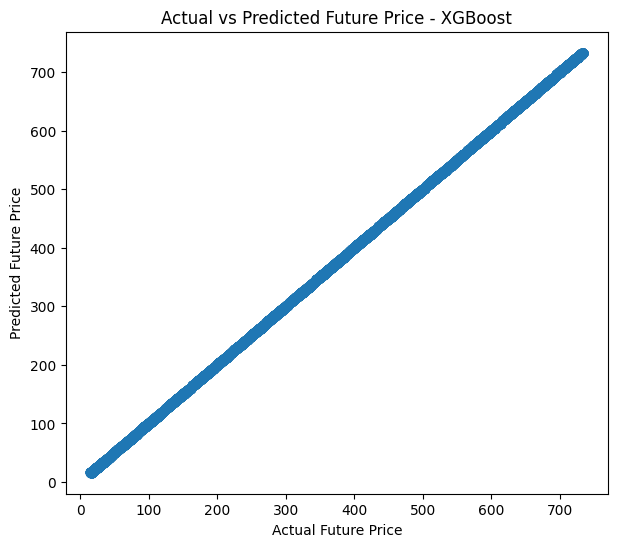

In [ ]:
# Actual vs Predicted
plt.figure(figsize=(7,6))

plt.scatter(
    y_test_r,
    y_pred_xgb_reg,
    alpha=0.5
)

plt.xlabel("Actual Future Price")
plt.ylabel("Predicted Future Price")

plt.title(
    "Actual vs Predicted Future Price - XGBoost"
)

plt.show()

In [ ]:
xgb_preprocessor = xgb_regressor.named_steps["preprocessor"]

xgb_model = xgb_regressor.named_steps["regressor"]

feature_names = xgb_preprocessor.get_feature_names_out()

importance = xgb_model.feature_importances_

reg_feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
}).sort_values(
    "Importance",
    ascending=False
)

reg_feature_importance.head(20)

,Feature,Importance
2,num__Price_in_Lakhs,9.997675e-01
808,"cat__Amenities_Playground, Garden, Pool",8.314562e-07
131,cat__Locality_Locality_152,7.134080e-07
3,num__Price_per_SqFt,7.021986e-07
656,"cat__Amenities_Garden, Clubhouse, Gym, Pool, P...",6.827522e-07
129,cat__Locality_Locality_150,6.604743e-07
180,cat__Locality_Locality_197,6.529735e-07
811,"cat__Amenities_Playground, Garden, Pool, Gym",6.511405e-07
786,"cat__Amenities_Playground, Clubhouse, Garden, ...",6.474348e-07
143,cat__Locality_Locality_163,6.382643e-07


STEP - 4 :ML FLOW INTEGRATION

In [ ]:
!pip install mlflow -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 1.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.2/44.2 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 38.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 50.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 45.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.4/267.4 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.4/228.4 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.5/136.5 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1

In [ ]:
import mlflow
import mlflow.sklearn
import joblib
import os

print("MLflow version:", mlflow.__version__)

MLflow version: 3.16.0


In [ ]:
# Creating ML Flow
mlflow.set_experiment(
    "Real_Estate_Investment_Advisor"
)

2026/09/09 07:57:27 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/09/09 07:57:27 INFO mlflow.store.db.utils: Updating database tables
2026/09/09 07:57:33 INFO mlflow.tracking.fluent: Experiment with name 'Real_Estate_Investment_Advisor' does not exist. Creating a new experiment.


<Experiment: artifact_location='/content/mlruns/1', creation_time=1788940653055, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1788940653055, lifecycle_stage='active', name='Real_Estate_Investment_Advisor', tags={}, trace_location=None, workspace='default'>

In [ ]:
# Log Logistic Regression
with mlflow.start_run(run_name="Logistic Regression"):

    mlflow.log_param("model", "Logistic Regression")
    mlflow.log_param("max_iter", 1000)

    mlflow.log_metric("accuracy", logistic_accuracy)
    mlflow.log_metric("precision", logistic_precision)
    mlflow.log_metric("recall", logistic_recall)
    mlflow.log_metric("f1_score", logistic_f1)
    mlflow.log_metric("roc_auc", logistic_auc)

    mlflow.set_tag("task", "classification")
    mlflow.set_tag("target", "Good_Investment")

print("Logistic Regression logged successfully!")

Logistic Regression logged successfully!


In [ ]:
# Random Forest Classifier
with mlflow.start_run(run_name="Random Forest Classifier"):

    mlflow.log_param("model", "Random Forest Classifier")
    mlflow.log_param("random_state", 42)

    mlflow.log_metric("accuracy", rf_accuracy)
    mlflow.log_metric("precision", rf_precision)
    mlflow.log_metric("recall", rf_recall)
    mlflow.log_metric("f1_score", rf_f1)
    mlflow.log_metric("roc_auc", rf_auc)

    mlflow.set_tag("task", "classification")
    mlflow.set_tag("target", "Good_Investment")

print("Random Forest Classifier logged successfully!")

Random Forest Classifier logged successfully!


In [ ]:
# XGBoost Classifier
with mlflow.start_run(run_name="XGBoost Classifier"):

    mlflow.log_param("model", "XGBoost Classifier")

    mlflow.log_metric("accuracy", xgb_accuracy)
    mlflow.log_metric("precision", xgb_precision)
    mlflow.log_metric("recall", xgb_recall)
    mlflow.log_metric("f1_score", xgb_f1)
    mlflow.log_metric("roc_auc", xgb_auc)

    mlflow.set_tag("task", "classification")
    mlflow.set_tag("target", "Good_Investment")

print("XGBoost Classifier logged successfully!")

XGBoost Classifier logged successfully!


In [ ]:
# Log Linear Regression
with mlflow.start_run(run_name="Linear Regression"):

    mlflow.log_param("model", "Linear Regression")

    mlflow.log_metric("MAE", mae_linear)
    mlflow.log_metric("RMSE", rmse_linear)
    mlflow.log_metric("R2", r2_linear)

    mlflow.set_tag("task", "regression")
    mlflow.set_tag("target", "Future_Price_5Y")

print("Linear Regression logged successfully!")

Linear Regression logged successfully!


In [ ]:
# Log Random Forest Regressor
with mlflow.start_run(run_name="Random Forest Regressor"):

    mlflow.log_param("model", "Random Forest Regressor")
    mlflow.log_param("random_state", 42)

    mlflow.log_metric("MAE", mae_rf)
    mlflow.log_metric("RMSE", rmse_rf)
    mlflow.log_metric("R2", r2_rf)

    mlflow.set_tag("task", "regression")
    mlflow.set_tag("target", "Future_Price_5Y")

print("Random Forest Regressor logged successfully!")

Random Forest Regressor logged successfully!


In [ ]:
# Log XGBoost Regressor
with mlflow.start_run(run_name="XGBoost Regressor"):

    mlflow.log_param("model", "XGBoost Regressor")

    mlflow.log_metric("MAE", mae_xgb)
    mlflow.log_metric("RMSE", rmse_xgb)
    mlflow.log_metric("R2", r2_xgb)

    mlflow.set_tag("task", "regression")
    mlflow.set_tag("target", "Future_Price_5Y")

print("XGBoost Regressor logged successfully!")

XGBoost Regressor logged successfully!


In [ ]:
# Saving classification model
joblib.dump(
    xgb_classifier,
    "classification_model.pkl"
)

print("Classification model saved successfully!")

Classification model saved successfully!


In [ ]:
# Saving regression model
joblib.dump(
    xgb_regressor,
    "regression_model.pkl"
)

print("Regression model saved successfully!")

Regression model saved successfully!


In [ ]:
import os

print("Classification model:",
      os.path.exists("classification_model.pkl"))

print("Regression model:",
      os.path.exists("regression_model.pkl"))

Classification model: True
Regression model: True


In [ ]:
with mlflow.start_run(run_name="Best Classification Model"):

    mlflow.log_param("model", "XGBoost Classifier")
    mlflow.log_param("purpose", "Good Investment Prediction")

    mlflow.log_metric("accuracy", xgb_accuracy)
    mlflow.log_metric("precision", xgb_precision)
    mlflow.log_metric("recall", xgb_recall)
    mlflow.log_metric("f1_score", xgb_f1)
    mlflow.log_metric("roc_auc", xgb_auc)

    mlflow.log_artifact("classification_model.pkl")

    mlflow.set_tag("task", "classification")
    mlflow.set_tag("target", "Good_Investment")
    mlflow.set_tag("best_model", "yes")

print("Best classification model logged!")

Best classification model logged!


In [ ]:
with mlflow.start_run(run_name="Best Regression Model"):

    mlflow.log_param("model", "XGBoost Regressor")
    mlflow.log_param("purpose", "5 Year Future Price Prediction")

    mlflow.log_metric("MAE", mae_xgb)
    mlflow.log_metric("RMSE", rmse_xgb)
    mlflow.log_metric("R2", r2_xgb)

    mlflow.log_artifact("regression_model.pkl")

    mlflow.set_tag("task", "regression")
    mlflow.set_tag("target", "Future_Price_5Y")
    mlflow.set_tag("best_model", "yes")

print("Best regression model logged!")

Best regression model logged!


In [ ]:
!mlflow ui --host 0.0.0.0 --port 5000 &

Backend store URI not provided. Using sqlite:///mlflow.db
Registry store URI not provided. Using backend store URI.
[MLflow] Security middleware enabled with default settings (localhost-only). To allow connections from other hosts, use --host 0.0.0.0 and configure --allowed-hosts and --cors-allowed-origins.
2026/09/09 08:07:59 INFO:     Uvicorn running on http://0.0.0.0:5000 (Press CTRL+C to quit)
2026/09/09 08:07:59 INFO:     Started parent process [43788]
/usr/local/lib/python3.13/dist-packages/mlflow/server/fastapi_app.py:23: StarletteDeprecationWarning: starlette.middleware.wsgi is deprecated and will be removed in a future release. Please refer to https://github.com/abersheeran/a2wsgi as a replacement.
  from starlette.middleware.wsgi import WSGIResponder, build_environ
/usr/local/lib/python3.13/dist-packages/mlflow/server/fastapi_app.py:23: StarletteDeprecationWarning: starlette.middleware.wsgi is deprecated and will be removed in a future release. Please refer to https://github.

In [ ]:
from google.colab.output import eval_js

url = eval_js("google.colab.kernel.proxyPort(5000)")
print(url)

https://5000-m-s-kkb-usw4a2-326h4548uag5z-a.us-west4-2.prod.colab.dev
